# Part 1 - Task 3: Data Exploration

In [1]:
import sys
sys.path.append('..')

import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = '../data/processed/995K_cleaned.csv'
FIG_DIR = '../figures'

SAMPLE_NROWS = 200000  # Use None later to read the entire dataset, but start with a smaller sample for testing

cols_to_keep = ['domain', 'type', 'content', 'content_normalized', 'content_processed']

df = pd.read_csv(
    DATA_PATH,
    usecols=cols_to_keep,
    nrows=SAMPLE_NROWS,
    low_memory=False,
    on_bad_lines='skip'
)

print(f"Shape: {df.shape}")
print("\nColumns and dtypes:")
print(df.dtypes)

Shape: (200000, 5)

Columns and dtypes:
domain                  str
type                  int64
content                 str
content_normalized      str
content_processed       str
dtype: object


We load the processed 995K dataset as a Pandas DataFrame, which gives a convenient tabular representation for mixed text and metadata fields. To keep memory usage manageable, we only load the columns needed for this exploration. The DataFrame design is appropriate because it makes it easy to group by label or domain, compute descriptive statistics, and build visualizations.

## Observation 1: Label Distribution
We examine whether the dataset is balanced between reliable (0) and fake (1) articles.

Label distribution:
  reliable: 90037 (45.0%)
  fake: 109963 (55.0%)


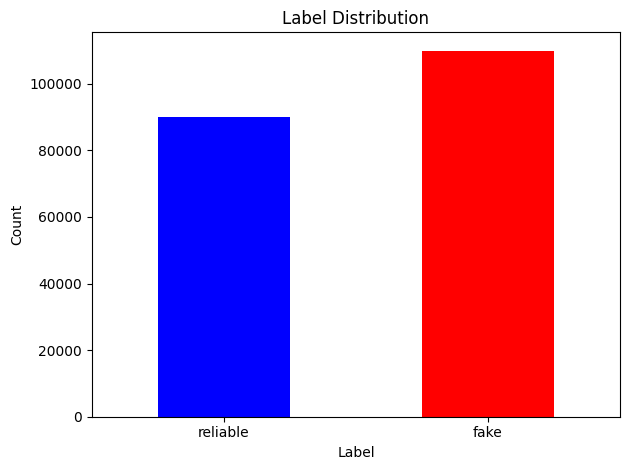

In [3]:
label_counts = df['type'].value_counts(dropna=False).sort_index()
label_names = {0: 'reliable', 1: 'fake'}

print("Label distribution:")
for label, count in label_counts.items():
    label_text = label_names.get(label, str(label))
    print(f"  {label_text}: {count} ({count / len(df) * 100:.1f}%)")

ax = label_counts.rename(index=label_names).plot(
    kind='bar',
    color=['blue', 'red'],)
ax.set_title('Label Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/labels_distribution_995k.png', dpi=200, bbox_inches='tight')
plt.show()

## Observation 2: Article Length Distribution per Label
We compare article lengths across labels using the processed text. Longer or shorter articles may indicate stylistic differences that are useful for fake-news detection.

reliable: mean=313.7, median=224.0, p95=828.0, max=11132
fake: mean=261.3, median=138.0, p95=859.0, max=10335


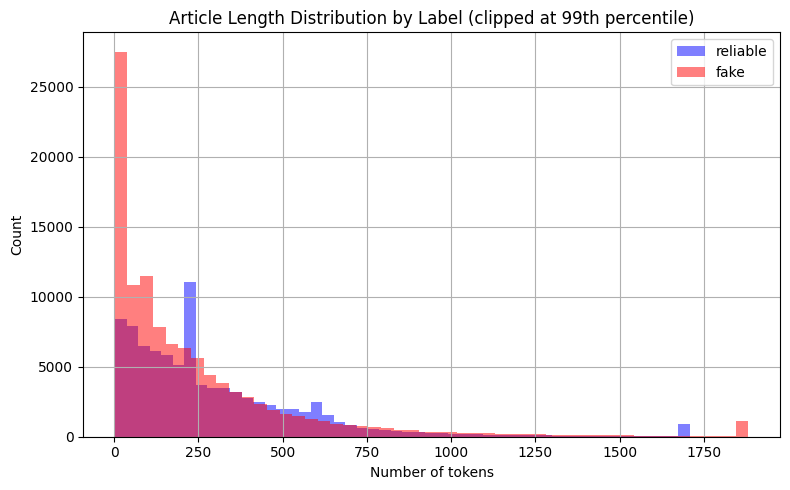

In [4]:
# Memory-friendly token count: avoid str.split().str.len()
df['content_length'] = df['content_processed'].fillna('').astype(str).str.count(r'\S+')

for label, name in {0: 'reliable', 1: 'fake'}.items():
    subset = df.loc[df['type'] == label, 'content_length']
    if len(subset) == 0:
        continue
    print(
        f"{name}: mean={subset.mean():.1f}, median={subset.median():.1f}, "
        f"p95={subset.quantile(0.95):.1f}, max={subset.max():.0f}"
    )
colors = {0: 'blue', 1: 'red'}

plt.figure(figsize=(8, 5))
for label, name in [(0, 'reliable'), (1, 'fake')]:
    subset = df.loc[df['type'] == label, 'content_length']
    if len(subset) == 0:
        continue
    subset.clip(upper=subset.quantile(0.99)).hist(
        bins=50,
        alpha=0.5,
        label=name,
        color=colors[label]
    )

plt.title('Article Length Distribution by Label (clipped at 99th percentile)')
plt.xlabel('Number of tokens')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/article_length_distribution_995k.png', dpi=200, bbox_inches='tight')
plt.show()

## Observation 3: Domain Analysis
We examine which domains contribute the most articles for each label. Strong domain concentration can reveal source artefacts that may influence later classification results.


Top 10 reliable domains:
domain
nytimes.com               37281
dailykos.com              18206
nationalreview.com         7970
dailycaller.com            2014
breitbart.com              1689
rawstory.com               1441
pjmedia.com                1363
thinkprogress.org          1011
weeklystandard.com          984
washingtonexaminer.com      897

Top 10 fake domains:
domain
beforeitsnews.com     21572
express.co.uk         11358
sputniknews.com        7679
abovetopsecret.com     4997
wikispooks.com         2946
pravda.ru              2516
lifezette.com          1883
wikileaks.org          1766
liberalamerica.org     1697
thepostemail.com       1498


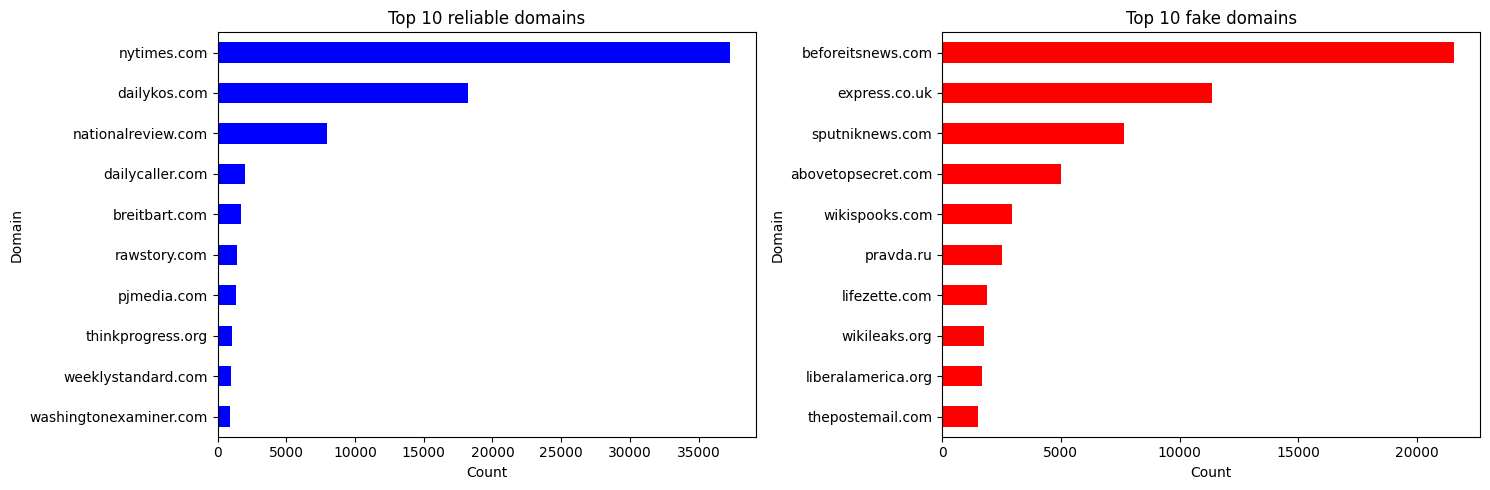

In [5]:
top_n = 10


for label, name in {0: 'reliable', 1: 'fake'}.items():
    top_domains = df.loc[df['type'] == label, 'domain'].fillna('missing').value_counts().head(top_n)
    print(f"\nTop {top_n} {name} domains:")
    print(top_domains.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (label, name) in zip(axes, [(0, 'reliable'), (1, 'fake')]):
    top_domains = df.loc[df['type'] == label, 'domain'].fillna('missing').value_counts().head(top_n)
    top_domains.sort_values().plot(kind='barh', ax=ax, color=colors[label])
    ax.set_title(f'Top {top_n} {name} domains')
    ax.set_xlabel('Count')
    ax.set_ylabel('Domain')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/domain_analysis_995k.png', dpi=200, bbox_inches='tight')
plt.show()

## Observation 4: Top-100 Words Before and After Preprocessing
We compare frequent words before and after stopword removal and stemming. This helps us see whether the preprocessing pipeline reduces noise and merges morphological variants.

In [6]:
def count_words(series):
    counter = Counter()
    for text in series.dropna().astype(str):
        counter.update(text.split())
    return counter

raw_counter = count_words(df['content_normalized'])
processed_counter = count_words(df['content_processed'])

words_raw = raw_counter.most_common(100)
words_processed = processed_counter.most_common(100)

print("Top 20 words in normalized content:")
for word, count in words_raw[:20]:
    print(f"  {word}: {count}")

print("\nTop 20 words in processed content:")
for word, count in words_processed[:20]:
    print(f"  {word}: {count}")

Top 20 words in normalized content:
  the: 5412438
  to: 2608731
  of: 2594979
  and: 2358887
  a: 2046372
  in: 1795532
  numtoken: 1453286
  that: 1133265
  is: 1045697
  for: 899117
  on: 728841
  it: 621710
  with: 581098
  as: 578262
  was: 509634
  are: 505649
  by: 487042
  this: 478134
  i: 458561
  be: 449907

Top 20 words in processed content:
  numtoken: 1480600
  said: 286974
  one: 243618
  year: 220319
  new: 218317
  us: 205692
  state: 202044
  would: 196913
  time: 194953
  peopl: 190906
  like: 179162
  also: 140516
  use: 136713
  make: 128900
  say: 125524
  get: 122040
  go: 121508
  even: 120508
  mr: 119291
  trump: 117553


We plot the top 30 most frequent words before and after preprocessing to visualize the effect of stopword removal and stemming.

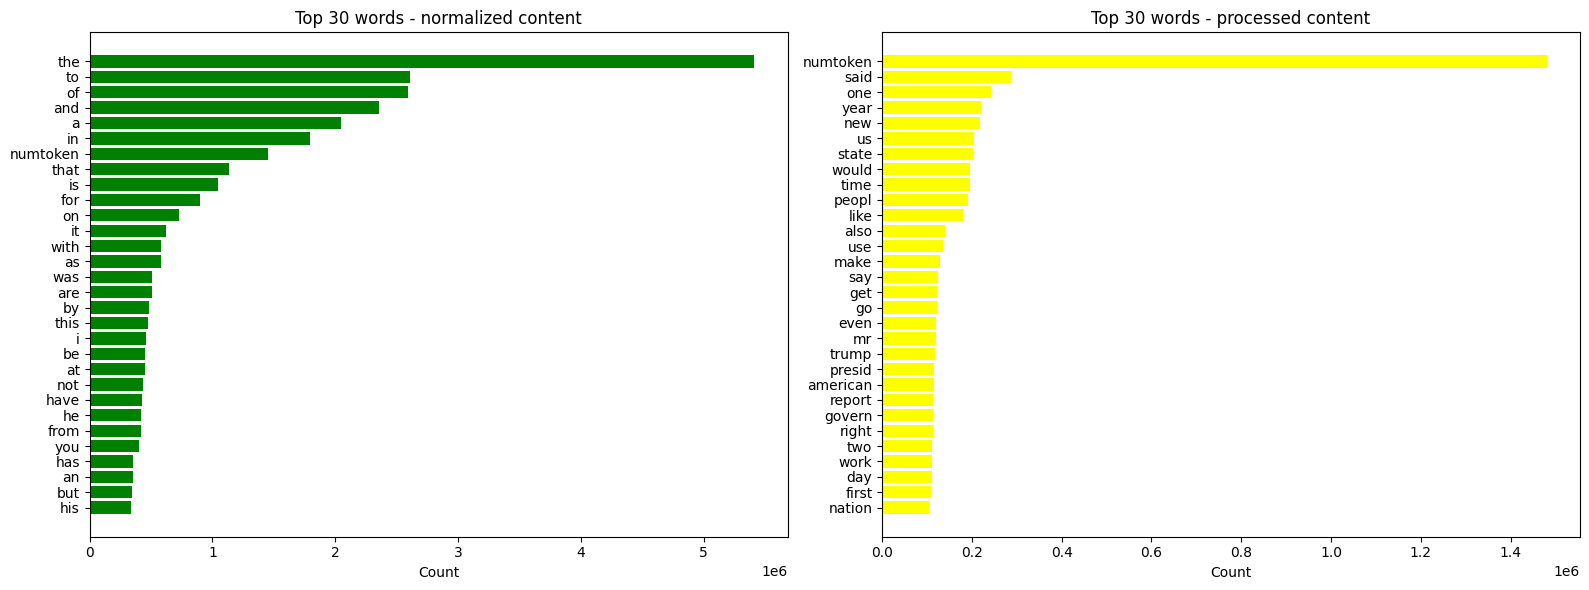

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

raw_labels, raw_counts = zip(*words_raw[:30])
processed_labels, processed_counts = zip(*words_processed[:30])

axes[0].barh(raw_labels[::-1], raw_counts[::-1], color='green')
axes[0].set_title('Top 30 words - normalized content')
axes[0].set_xlabel('Count')

axes[1].barh(processed_labels[::-1], processed_counts[::-1], color='yellow')
axes[1].set_title('Top 30 words - processed content')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/top_words_before_after_995k.png', dpi=200, bbox_inches='tight')
plt.show()

## Observation 5: Frequency of the 10,000 Most Frequent Words
A word-frequency curve can reveal whether the dataset follows a heavy-tailed distribution such as Zipf's law, which is common in natural language.

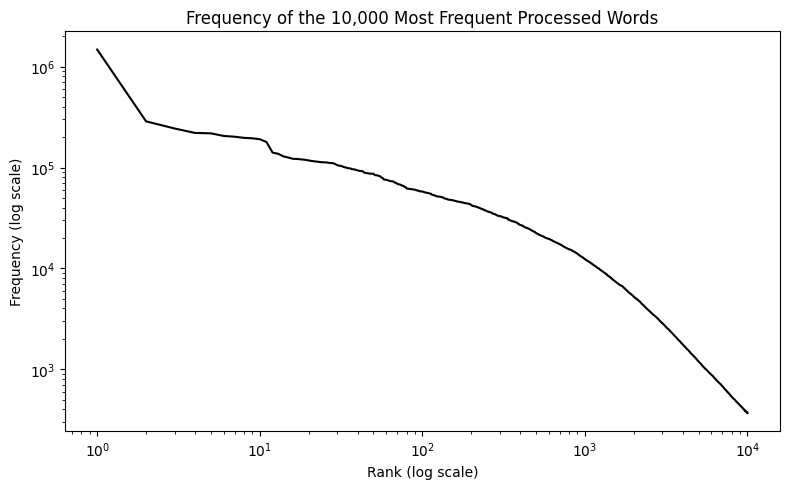

In [8]:
top_10000_counts = np.array([count for _, count in processed_counter.most_common(10000)])

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(top_10000_counts) + 1), top_10000_counts, color='black')
plt.xscale('log')
plt.yscale('log')
plt.title('Frequency of the 10,000 Most Frequent Processed Words')
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/top_10000_words_frequency_995k.png', dpi=200, bbox_inches='tight')
plt.show()

## Observation 6: Counts of URLs, Dates, and Numeric Values
We count simple textual artefacts that may differ between reliable and fake articles and could be useful as lightweight metadata-style features.

In [9]:
patterns = {
    'url_count': r'https?://\S+|www\.\S+',
    'date_count': r'\b\d{1,4}[-/.]\d{1,2}[-/.]\d{1,4}\b',
    'number_count': r'\b\d+\b',
}

for feature_name, pattern in patterns.items():
    df[feature_name] = df['content'].fillna('').astype(str).str.count(pattern)

for feature_name in patterns:
    series = df[feature_name]
    print(
        f"{feature_name}: total={series.sum()}, mean={series.mean():.2f}, "
        f"median={series.median():.2f}, p95={series.quantile(0.95):.2f}"
    )

for feature_name in patterns:
    print(f"\n{feature_name} by label:")
    grouped = df.groupby('type')[feature_name].agg(['mean', 'median'])
    grouped.index = grouped.index.map(lambda x: label_names.get(x, str(x)))
    print(grouped)

url_count: total=56108, mean=0.28, median=0.00, p95=1.00
date_count: total=27497, mean=0.14, median=0.00, p95=1.00
number_count: total=1991211, mean=9.96, median=4.00, p95=36.00

url_count by label:
              mean  median
type                      
reliable  0.118729     0.0
fake      0.413030     0.0

date_count by label:
              mean  median
type                      
reliable  0.151682     0.0
fake      0.125861     0.0

number_count by label:
               mean  median
type                       
reliable  11.559670     4.0
fake       8.643025     3.0


## Summary of Key Observations

This exploration can support several non-trivial observations about the processed 995K dataset:

1. **Class balance or imbalance:** the label distribution shows whether the classification task is naturally balanced or whether later models may need class weighting.
2. **Length differences between labels:** if fake and reliable articles differ systematically in length, this may indicate stylistic differences or source-specific artefacts.
3. **Strong domain concentration:** if a small number of domains dominate one label, a classifier may partly learn source patterns rather than only linguistic signals.
4. **Preprocessing changes the vocabulary substantially:** the comparison before and after preprocessing shows whether stopword removal and stemming successfully reduce noise and merge related word forms.
5. **Heavy-tailed word frequencies:** the log-log frequency curve for the 10,000 most frequent words typically suggests a Zipf-like pattern, which is expected in natural language.
6. **URLs, dates, and numbers may differ across labels:** these artefacts are simple but potentially informative indicators for fake-news detection.

Potential inherent issues in the data include domain bias, class imbalance, missing values, and the possibility that some metadata-like artefacts correlate with source rather than truthfulness.